# Обучение нейросетей — BatchNorm2d


В этой домашке вам нужно реализовать BatchNormalization-слой

In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import clear_output

import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.datasets as dsets
import torchvision.transforms as transforms
import torch.optim as optim
from torch.utils.data.sampler import SubsetRandomSampler

In [2]:
def seed_everything(seed: int):
    import random, os
    import numpy as np
    import torch

    torch.use_deterministic_algorithms(True)

    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = True

In [3]:
need_run_tests_and_training = 'google.colab' in str(get_ipython())
need_run_tests_and_training

True

In [9]:
# =====================================================================
# 1. ЗАДАНИЕ КОНСТАНТ (ПАРАМЕТРЫ АРХИТЕКТУРЫ И ОБУЧЕНИЯ)
# =====================================================================

# Размер одной картинки. Оригинальные картинки MNIST имеют размер 28x28 пикселей.
# 28 * 28 = 784. Мы будем вытягивать квадратную картинку в одну длинную строку (вектор).
# Это значит, что во входной матрице батча у нас будет ровно 784 столбца (признака).
input_size = 784

# Количество классов, которые мы хотим предсказывать.
# В датасете MNIST это цифры от 0 до 9, итого 10 штук.
# Это задает размер нашего самого последнего (выходного) слоя нейросети.
num_classes = 10

# Теперь матрица входных данных X на каждом шаге будет иметь размер [128 x 784].
# То есть 128 (из 60к) независимых картинок будут одновременно пролетать через твои слои.
batch_size = 128


# =====================================================================
# 2. ЗАГРУЗКА И ПОДГОТОВКА ДАННЫХ (DATASETS)
# Dataset — это просто "хранилище" на жестком диске. Он знает, где лежат картинки.
# =====================================================================

train_dataset = dsets.MNIST(
    # Папка, куда скачаются картинки. Если папки нет, PyTorch создаст её.
    root='./MNIST/',

    # Говорим PyTorch: "Дай нам тренировочную часть (60 000 картинок)".
    # На этих данных мы будем считать градиенты и обновлять веса матриц.
    train=True,

    # Самая важная трансформация. Оригинальные картинки хранятся в формате PIL (от 0 до 255).
    # Нейросети не умеют работать с числами до 255, градиенты взорвутся.
    # ToTensor() делает две вещи:
    # 1. Превращает картинку в тензор (матрицу PyTorch).
    # 2. Сжимает пиксели из диапазона [0...255] в диапазон от [0.0 ... 1.0].
    transform=transforms.ToTensor(),

    # Разрешаем скачать датасет из интернета, если его еще нет в папке './MNIST/'.
    download=True
)

test_dataset = dsets.MNIST(
    root='./MNIST/',

    # Говорим PyTorch: "А теперь дай нам тестовую часть (10 000 картинок)".
    # Эту стопку экзаменационных работ сеть НИКОГДА не увидит во время обучения.
    # Мы используем их только для проверки (чтобы убедиться, что сеть не просто зазубрила ответы).
    train=False,

    # Точно так же превращаем их в матрицы с числами от 0.0 до 1.0.
    transform=transforms.ToTensor()
)


# =====================================================================
# 3. СОЗДАНИЕ ЗАГРУЗЧИКОВ (DATALOADERS)
# DataLoader — это конвейерная лента. Она берет данные из Dataset и
# автоматически нарезает их на те самые батчи (матрицы [128 x 784]).
# =====================================================================

train_loader = torch.utils.data.DataLoader(
    # Указываем, откуда конвейеру брать данные (из наших 60 000 тренировочных картинок).
    dataset=train_dataset,

    # Говорим конвейеру: "Выдавай мне стопки ровно по 128 штук за один раз".
    batch_size=batch_size,

    # КРИТИЧЕСКИ ВАЖНО: Перемешивание (Shuffle).
    # Если не перемешать, сеть сначала увидит тысячу нулей, потом тысячу единиц и т.д.
    # Она будет забывать предыдущие цифры.
    # Shuffle=True перед каждой эпохой тасует все 60 000 картинок, как колоду карт,
    # чтобы в каждом батче из 128 штук были разные случайные цифры.
    shuffle=True
)

test_loader = torch.utils.data.DataLoader(
    # Указываем тестовое хранилище (10 000 картинок).
    dataset=test_dataset,

    # Здесь мы тоже выдаем работы стопками по 128 штук, чтобы проверять их быстрее (параллельно).
    batch_size=batch_size,

    # Перемешивание отключено (False).
    # На этапе экзамена нам абсолютно неважно, в каком порядке проверять работы.
    # Сеть здесь не учится (веса не обновляются), поэтому тратить ресурсы процессора
    # на тасование колоды не имеет смысла.
    shuffle=False
)


Определим ряд стандартных функций с прошлых семинаров

In [10]:
# =====================================================================
# 1. ФУНКЦИЯ ОБУЧЕНИЯ ЗА ОДНУ ЭПОХУ (Один проход по всему датасету)
# =====================================================================
def train_epoch(model, optimizer, batchsize=32):
    # Создаем пустые списки, куда будем записывать ошибку (loss) и точность (accuracy) каждого батча
    loss_log, acc_log = [], []

    # КРИТИЧЕСКИ ВАЖНО: Перевод модели в режим обучения!
    # Именно здесь ломаются 90% программ. Эта команда говорит слоям BatchNorm:
    # "Считайте среднее и дисперсию по текущему батчу и обновляйте свой блокнот глобальной статистики!"
    # Также она включает слои Dropout (если они есть).
    model.train()

    # train_loader выдает нам данные порциями (батчами) по 128 штук.
    # x_batch - это матрица картинок [128, 1, 28, 28].
    # y_batch - это вектор правильных ответов (цифры от 0 до 9) длиной 128.
    for batch_num, (x_batch, y_batch) in enumerate(train_loader):
        data = x_batch
        target = y_batch

        # 1. ОБНУЛЕНИЕ ГРАДИЕНТОВ
        # В PyTorch градиенты накапливаются (складываются) при каждом вызове .backward().
        # Если не обнулить их перед новым батчем, сеть будет пытаться учиться
        # на смеси ошибок текущего и всех предыдущих батчей. Это приведет к хаосу.
        optimizer.zero_grad()

        # 2. ПРЯМОЙ ПРОХОД (FORWARD PASS)
        # Мы кидаем все 128 картинок в модель ОДНОВРЕМЕННО.
        # Выход (output) - это матрица [128 x 10] (128 картинок, 10 вероятностей для каждой).
        output = model(data)

        # 3. ПОДСЧЕТ ТОЧНОСТИ (ACCURACY)
        # torch.max(output, 1) ищет максимальное значение в каждой строке (из 10 вероятностей).
        # Он возвращает два тензора: сами максимальные значения и их индексы.
        # Нам нужны индексы [1] (ведь индекс от 0 до 9 - это и есть предсказанная цифра!).
        pred = torch.max(output, 1)[1]

        # Сравниваем предсказания с правильными ответами (target).
        # eq() дает массив из True/False. float() превращает их в 1.0 и 0.0.
        # mean() считает среднее арифметическое. Например, 0.95 (95% картинок угаданы верно).
        acc = torch.eq(pred, y_batch).float().mean()
        acc_log.append(acc)

        # 4. ПОДСЧЕТ ОШИБКИ (LOSS)
        # F.nll_loss - Negative Log Likelihood loss. Сравнивает предсказания сети с правильными ответами.
        # .cpu() переносит тензор с видеокарты в оперативную память компьютера (если считали на GPU).
        loss = F.nll_loss(output, target).cpu()

        # 5. ОБРАТНОЕ РАСПРОСТРАНЕНИЕ (BACKPROPAGATION)
        # Магия математики. PyTorch берет число loss и бежит в обратную сторону по всей сети,
        # считая производные (градиенты) для каждой матрицы весов, гаммы и беты.
        loss.backward()

        # 6. ШАГ ОПТИМИЗАТОРА
        # Оптимизатор (например, SGD или Adam) берет посчитанные градиенты и
        # физически сдвигает веса матриц (W = W - learning_rate * grad), чтобы сеть стала умнее.
        optimizer.step()

        # loss.item() вытаскивает чистое число (float) из тензора PyTorch,
        # чтобы оно не тянуло за собой гигантский граф вычислений и не забивало память.
        loss = loss.item()
        loss_log.append(loss)

    return loss_log, acc_log

# =====================================================================
# 2. ФУНКЦИЯ ТЕСТИРОВАНИЯ (Экзамен без подглядывания в ответы)
# =====================================================================
def test(model):
    loss_log, acc_log = [], []

    # КРИТИЧЕСКИ ВАЖНО: Перевод модели в режим оценки (evaluation)!
    # Наш BatchNorm отключает расчет статистики по батчу. Теперь он нормализует картинки,
    # используя только глобальные средние значения (Running Mean), накопленные за время обучения.
    model.eval()

    # Идем по тестовым данным (10 000 картинок, которых сеть никогда не видела)
    for batch_num, (x_batch, y_batch) in enumerate(test_loader):
        data = x_batch
        target = y_batch

        # Прямой проход. Заметь: здесь НЕТ optimizer.zero_grad(),
        # НЕТ loss.backward() и НЕТ optimizer.step(). Мы только смотрим на результат, но не учимся!
        output = model(data)
        loss = F.nll_loss(output, target).cpu()

        # Считаем точность так же, как и при обучении
        pred = torch.max(output, 1)[1]
        acc = torch.eq(pred, y_batch).float().mean()
        acc_log.append(acc)

        loss = loss.item()
        loss_log.append(loss)

    return loss_log, acc_log

# =====================================================================
# 3. ФУНКЦИЯ ОТРИСОВКИ ГРАФИКОВ (Визуализация обучения)
# =====================================================================
def plot_history(train_history, val_history, title='loss'):
    plt.figure()
    plt.title('{}'.format(title))

    # Рисуем синюю линию - это график того, как менялась ошибка (или точность) на ТРЕНИРОВОЧНОМ датасете.
    plt.plot(train_history, label='train', zorder=1)

    # Валидационная (тестовая) история - это список из координат (x, y).
    points = np.array(val_history)

    # Рисуем оранжевые крестики - это результаты Экзамена (валидации) в конце каждой эпохи.
    # Если синяя линия идет вниз (loss падает), а оранжевые крестики пошли вверх —
    # значит сеть переобучилась (вызубрила тренировочные данные, но не понимает сути).
    plt.scatter(points[:, 0], points[:, 1], marker='+', s=180, c='orange', label='val', zorder=2)

    plt.xlabel('train steps')
    plt.legend(loc='best')
    plt.grid()
    plt.show()

# =====================================================================
# 4. ГЛАВНАЙ ЦИКЛ ОБУЧЕНИЯ (Оркестратор)
# =====================================================================
def train(model, opt, n_epochs):

    # Костыль для системы проверки (чтобы код не висел бесконечно, если его просто тестируют)
    if not need_run_tests_and_training:
        return

    # Глобальные хранилища истории за все эпохи
    train_log, train_acc_log = [], []
    val_log, val_acc_log = [], []

    # Запускаем цикл на n_epochs (сколько раз мы прогоним ВЕСЬ датасет из 60к картинок через сеть)
    for epoch in range(n_epochs):
        print("Epoch {0} of {1}".format(epoch, n_epochs))

        # 1. УЧИМСЯ: Вызываем функцию тренировки. Она обновит веса и вернет логи за эту эпоху.
        train_loss, train_acc = train_epoch(model, opt, batchsize=batch_size)

        # 2. ПРОВЕРЯЕМ: Вызываем функцию тестирования. Веса заморожены, сдаем экзамен.
        val_loss, val_acc = test(model)

        # Добавляем результаты эпохи в глобальную историю (extend добавляет элементы списка в конец другого списка)
        train_log.extend(train_loss)
        train_acc_log.extend(train_acc)

        # Вычисляем, на каком "шаге" мы находимся, чтобы красиво поставить крестик на графике.
        # Один шаг = один батч.
        steps = train_dataset.train_labels.shape[0] / batch_size
        val_log.append((steps * (epoch + 1), np.mean(val_loss)))
        val_acc_log.append((steps * (epoch + 1), np.mean(val_acc)))

        # Очищаем вывод в консоли (чтобы графики не рисовались друг под другом простыней,
        # а обновлялись на одном и том же месте, как анимация)
        clear_output()

        # Рисуем график ошибки (Loss)
        plot_history(train_log, val_log)

        # Рисуем график точности (Accuracy)
        plot_history(train_acc_log, val_acc_log, title='accuracy')

        # Печатаем цифры в консоль: средняя ошибка и средняя точность на экзамене
        print("Epoch: {2}, val loss: {0}, val accuracy: {1}".format(np.mean(val_loss), np.mean(val_acc), epoch))

Создайте простейшую однослойную модель - однослойную полносвязную сеть и обучите ее с параметрами оптимизации, заданными ниже.

In [19]:
# =====================================================================
# СОЗДАНИЕ АРХИТЕКТУРЫ МОДЕЛИ (ОДНОСЛОЙНАЯ СЕТЬ)
# =====================================================================

model = nn.Sequential(
    # -----------------------------------------------------------------
    # 1. nn.Flatten(1) - "Расплющивание" картинки
    # -----------------------------------------------------------------
    # Вспоминаем нашу теорию! Из DataLoader'а картинки приходят в виде 4D-тензора:
    # [batch_size, channels, height, width] -> [128, 1, 28, 28].
    # Линейный слой (nn.Linear) не умеет работать с кубиками 28x28. Ему нужна плоская строка.
    #
    # Параметр '1' означает: "Начни расплющивать тензор начиная с измерения №1 (channels)".
    # Измерение №0 (batch_size = 128) мы НЕ трогаем! Картинки не должны смешаться друг с другом.
    #
    # Что происходит с формой тензора:
    # ДО:   [128, 1, 28, 28]
    # ПОСЛЕ: [128, 784] (потому что 1 * 28 * 28 = 784)
    # Итог: Мы получили ту самую плоскую 2D-матрицу данных X, которую обсуждали!
    nn.Flatten(1),

    # -----------------------------------------------------------------
    # 2. nn.Linear(input_size, num_classes) - Линейная комбинация (Веса)
    # -----------------------------------------------------------------
    # Это "сердце" нашей однослойной сети. Тот самый набор учителей с шаблонами.
    # input_size = 784 (каждый "учитель" смотрит на 784 пикселя).
    # num_classes = 10 (у нас 10 "учителей", каждый ищет свою цифру от 0 до 9).

    # т.е сразу для каждой картинки ПОЛУЧАЕМ 10 ЛК из 784 признаков -> 10 сырых логитов
    # Математика под капотом: Z = X * W + b
    # Матрица X: [128, 784]
    # Матрица W: [784, 10]

    # Форма тензора на выходе:
    # ПОСЛЕ: [128, 10].
    # Для каждой из 128 картинок мы получили 10 "сырых" баллов (логитов).
    # Поскольку сеть очень простая (в ней нет скрытых слоев 128 -> 64 -> 32, которые мы обсуждали, а идет прямой прыжок 784 -> 10),
    # она не сможет выучить сложные нелинейные зависимости. Это просто поиск линейных шаблонов (грубо говоря, наложение трафарета).
    nn.Linear(input_size, num_classes),

    # -----------------------------------------------------------------
    # 3. nn.LogSoftmax(dim=-1) - Превращение баллов в вероятности
    # -----------------------------------------------------------------
    # Сырые баллы могут быть любыми (например, -50 или +120).
    # Softmax превращает их в вероятности (от 0 до 1, сумма равна 1.0).
    # Но мы используем LogSoftmax (берем логарифм от вероятности).
    #
    # ЗАЧЕМ Log? В функции train_epoch мы используем функцию потерь F.nll_loss
    # (Negative Log Likelihood). Она математически требует, чтобы на вход подавались
    # именно логарифмы вероятностей, а не сами вероятности. Это спасает от
    # вычислительной нестабильности (когда процессор округляет слишком маленькие дроби до нуля).
    #
    # dim=-1 означает: "примени Softmax вдоль последней оси".
    # Последняя ось - это наши 10 классов. То есть мы считаем 100% вероятность
    # для каждой отдельной картинки, не смешивая баллы разных картинок в батче.
    #
    # Форма тензора не меняется: [128, 10].
    nn.LogSoftmax(dim=-1)
)

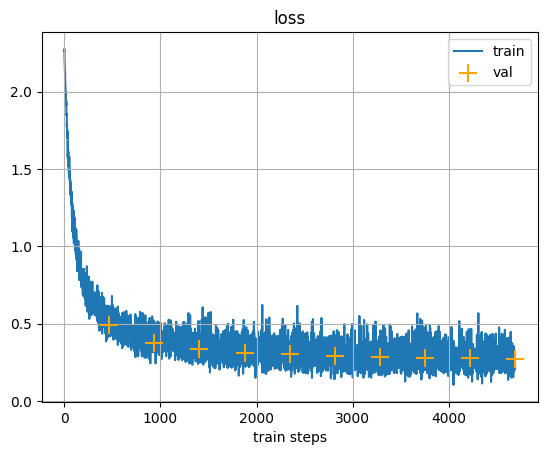

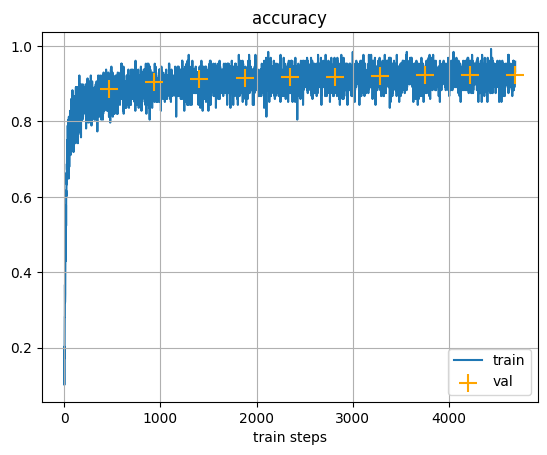

Epoch: 9, val loss: 0.2733073274168787, val accuracy: 0.9235561490058899


In [17]:
# =====================================================================
# НАСТРОЙКА ОПТИМИЗАТОРА И ЗАПУСК ОБУЧЕНИЯ
# =====================================================================

# Оптимизатор Adam - это умный алгоритм градиентного спуска.
# В отличие от обычного SGD, он подбирает индивидуальную скорость обучения
# для каждого отдельного веса, учитывая "инерцию" прошлых шагов.
#
# model.parameters() - мы передаем оптимизатору ссылку на все матрицы весов (W)
# и смещений (b) внутри нашей модели, чтобы он имел право их изменять.
# lr=0.0005 (Learning Rate) - размер шага. Насколько сильно мы меняем веса
# при каждой ошибке. Если поставить слишком много (0.1), сеть будет перепрыгивать
# минимум. Если слишком мало (0.000001), обучение займет вечность.
opt = torch.optim.Adam(model.parameters(), lr=0.0005)

# Запускаем нашу главную функцию-оркестратор.
# Передаем ей нашу модель, наш настроенный оптимизатор и говорим:
# "Прогони весь датасет (60 000 картинок) через сеть 10 раз (10 эпох)".
train(model, opt, 10)

Параметром обученной нейросети является матрица весов, в которой каждому классу соответствует один из 784-мерных столбцов. Визуализируйте обученные векторы для каждого из классов, сделав их двумерными изображениями 28-28. Для визуализации можно воспользоваться кодом для визуализации MNIST-картинок с предыдущих семинаров.

In [23]:
# =====================================================================
# ВИЗУАЛИЗАЦИЯ "МЫСЛЕЙ" НЕЙРОСЕТИ (ВЕСОВЫХ МАТРИЦ)
# =====================================================================

# 1. СМОТРИМ НА РАЗМЕРНОСТЬ
# Наша модель была создана через nn.Sequential и имеет 3 шага:
# 0: nn.Flatten
# 1: nn.Linear(784, 10)
# 2: nn.LogSoftmax
# Обращаясь к _modules['1'], мы вытаскиваем именно линейный слой.
# Вызов .weight.shape вернет [10, 784].
# Это значит: 10 строк (по одной на каждую цифру) и 784 столбца (веса для каждого пикселя).
model._modules['1'].weight.shape

torch.Size([10, 784])

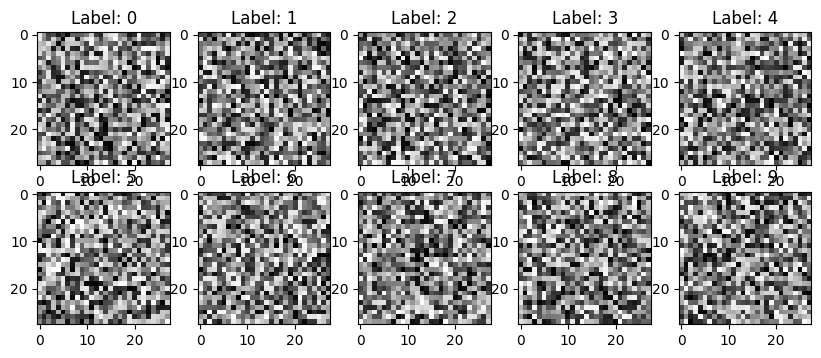

In [24]:
# 2. ИЗВЛЕКАЕМ ВЕСА ИЗ ВИДЕОКАРТЫ В NUMPY
# model._modules['1'].weight - это тензор PyTorch.
# .detach() - КРИТИЧЕСКИ ВАЖНАЯ ФУНКЦИЯ! Тензоры в PyTorch намертво привязаны
# к "графу вычислений" (чтобы считать градиенты при обучении).
# Метод detach() "отрывает" тензор от этого графа, превращая его в обычные числа.
# .numpy() - переводит тензор PyTorch в стандартный массив библиотеки NumPy,
# потому что библиотека для рисования графиков (matplotlib) понимает только NumPy.
weights = model._modules['1'].weight.detach().numpy()

# 3. НАСТРОЙКА ХОЛСТА
# Создаем окно для рисования размером 10 на 10 дюймов.
plt.figure(figsize=[10, 10])

# 4. ЦИКЛ ПО ВСЕМ 10 КЛАССАМ (ЦИФРАМ от 0 до 9)
for i in range(10):
    # plt.subplot создает сетку графиков.
    # (5, 5) значит, что сетка будет 5 строк на 5 столбцов (вмещает 25 картинок).
    # i + 1 - это порядковый номер текущей картинки (от 1 до 10).
    # Программа будет рисовать их слева направо, сверху вниз.
    plt.subplot(5, 5, i + 1)

    # Пишем заголовок над каждой картинкой (например, "Label: 0")
    plt.title("Label: %i" % i)

    # 5. МАГИЯ ВОССТАНОВЛЕНИЯ ПРОСТРАНСТВА
    # weights[i] берет i-ю строку из нашей матрицы [10, 784]. То есть вектор длиной 784.
    # .reshape([28, 28]) берет эту плоскую макаронину и сгибает ее обратно
    # в квадратную матрицу 28 на 28 пикселей.
    # cmap='gray' заставляет matplotlib рисовать матрицу в оттенках серого,
    # а не в стандартных кислотных (сине-желтых) цветах.
    plt.imshow(weights[i].reshape([28, 28]), cmap='gray');

## BatchNorm2d

Реализуйте BatchNormalization слой для сверточной сети

* `nn.Parameter` нужно использовать для того, чтобы определить обучаемые параметры для сети
* буфферы нужно использовать для других тензоров, которые должны возвращаться в `state_dict()` модели, но для которых не нужно вычислять градиенты
* В чем разница между register_buffer, register_parameter: [тык](https://stackoverflow.com/questions/57540745/what-is-the-difference-between-register-parameter-and-register-buffer-in-pytorch)
* для буфферов не должны считаться градиенты, используте `.detach()` при операциях с тензорами, по которым считаются градиенты
* Для того, чтобы заработал [broadcast](https://pytorch.org/docs/stable/notes/broadcasting.html) между тензорами разных рзаменностей, можно использовать .view(1, -1, 1, 1)


In [25]:
torch.arange(3).shape, torch.arange(3).view(1, -1, 1, 1).shape

(torch.Size([3]), torch.Size([1, 3, 1, 1]))

In [26]:
torch.zeros([2, 3, 4, 4]) - torch.arange(3).view(1, -1, 1, 1)

tensor([[[[ 0.,  0.,  0.,  0.],
          [ 0.,  0.,  0.,  0.],
          [ 0.,  0.,  0.,  0.],
          [ 0.,  0.,  0.,  0.]],

         [[-1., -1., -1., -1.],
          [-1., -1., -1., -1.],
          [-1., -1., -1., -1.],
          [-1., -1., -1., -1.]],

         [[-2., -2., -2., -2.],
          [-2., -2., -2., -2.],
          [-2., -2., -2., -2.],
          [-2., -2., -2., -2.]]],


        [[[ 0.,  0.,  0.,  0.],
          [ 0.,  0.,  0.,  0.],
          [ 0.,  0.,  0.,  0.],
          [ 0.,  0.,  0.,  0.]],

         [[-1., -1., -1., -1.],
          [-1., -1., -1., -1.],
          [-1., -1., -1., -1.],
          [-1., -1., -1., -1.]],

         [[-2., -2., -2., -2.],
          [-2., -2., -2., -2.],
          [-2., -2., -2., -2.],
          [-2., -2., -2., -2.]]]])

In [31]:
from typing import Optional, Any
import torch
import torch.nn as nn
import torch.nn.functional as F

class BatchNorm2dLayer(nn.Module):
    """
    https://pytorch.org/docs/stable/generated/torch.nn.BatchNorm2d.html
    """

    def __init__(self, num_features, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True, device=None):
        super().__init__()

        self.eps = eps
        self.momentum = momentum
        self.affine = affine
        self.num_features = num_features

        self.track_running_stats = track_running_stats

        if self.affine:
            self.weight = nn.Parameter(torch.ones(num_features, device=device), requires_grad=True)
            self.bias = nn.Parameter(torch.zeros(num_features, device=device), requires_grad=True)
        else:
            self.register_parameter("weight", None)
            self.register_parameter("bias", None)

        if self.track_running_stats:
            self.register_buffer('running_mean', torch.zeros(num_features, device=device))
            self.register_buffer('running_var', torch.ones(num_features, device=device))

            self.register_buffer('num_batches_tracked',
                                 torch.tensor(0, dtype=torch.long, device=device))

            self.num_batches_tracked: Optional[torch.Tensor]
        else:
            self.register_buffer("running_mean", None)
            self.register_buffer("running_var", None)
            self.register_buffer("num_batches_tracked", None)


    def forward(self, input_tensor):
        # ---------------------------------------------------------------------
        # ШАГ 1: ВЫЧИСЛЕНИЕ СТАТИСТИКИ ТЕКУЩЕГО БАТЧА
        # ---------------------------------------------------------------------
        # На вход приходит тензор размерности [N, C, H, W]
        # Где: N - размер батча, C - каналы, H - высота, W - ширина.
        #
        # Мы хотим получить 1 число среднего для КАЖДОГО канала.
        # Поэтому мы "схлопываем" (усредняем) размерности 0 (N), 2 (H) и 3 (W).
        # Формула среднего: \mu_c = \frac{1}{N \cdot H \cdot W} \sum_{n, h, w} x_{n, c, h, w}
        batch_mean = input_tensor.mean(dim=(0, 2, 3))

        # Формула дисперсии: \sigma_c^2 = \frac{1}{N \cdot H \cdot W} \sum_{n, h, w} (x_{n, c, h, w} - \mu_c)^2
        # Согласно документации PyTorch, для нормализации самого батча используется
        # смещенная (смещенная на N, а не N-1) оценка дисперсии, поэтому unbiased=False.
        batch_var = input_tensor.var(dim=(0, 2, 3), unbiased=False)


        # ---------------------------------------------------------------------
        # ШАГ 2: ОБНОВЛЕНИЕ ГЛОБАЛЬНЫХ БУФЕРОВ (Только в режиме обучения)
        # ---------------------------------------------------------------------
        if self.track_running_stats and self.training:
            # Важный нюанс: для Running Stats (глобальной статистики датасета)
            # PyTorch математически требует использовать несмещенную (unbiased=True) дисперсию.
            # Она умножается на поправочный коэффициент n/(n-1).
            unbiased_var = input_tensor.var(dim=(0, 2, 3), unbiased=True)

            # Мы используем .detach(), чтобы граф вычислений (Backprop) обрывался здесь.
            # Градиенты не должны течь через Running Stats, так как они не обучаются оптимизатором!
            #
            # Формула EMA (Экспоненциальное скользящее среднее):
            # \mu_{running} = (1 - momentum) * \mu_{running} + momentum * \mu_{batch}
            self.running_mean = (1 - self.momentum) * self.running_mean + self.momentum * batch_mean.detach()
            self.running_var = (1 - self.momentum) * self.running_var + self.momentum * unbiased_var.detach()

            # Увеличиваем счетчик батчей (полезно для некоторых продвинутых расчетов)
            self.num_batches_tracked += 1


        # ---------------------------------------------------------------------
        # ШАГ 3: ВЫБОР РАБОЧЕЙ СТАТИСТИКИ (Train vs Eval)
        # ---------------------------------------------------------------------
        if self.track_running_stats and not self.training:
            # Если мы на экзамене (model.eval()), мы игнорируем статистику текущей картинки
            # и берем накопленный глобальный опыт из буферов.
            mean_to_use = self.running_mean
            var_to_use = self.running_var
        else:
            # Во время обучения (или если track_running_stats=False) нормализуем по текущему батчу
            mean_to_use = batch_mean
            var_to_use = batch_var


        # ---------------------------------------------------------------------
        # ШАГ 4: BROADCASTING И НОРМАЛИЗАЦИЯ
        # ---------------------------------------------------------------------
        # Сейчас mean_to_use имеет размерность [C] (просто одномерный вектор).
        # Мы не можем напрямую вычесть вектор [C] из тензора [N, C, H, W].

        # Вызов .view(1, -1, 1, 1) превращает вектор [C] в тензор [1, C, 1, 1].
        # Теперь PyTorch автоматически скопирует (broadcast) эти значения на все
        # N картинок и на все HxW пикселей внутри каждого канала.
        mean_view = mean_to_use.view(1, -1, 1, 1)
        var_view = var_to_use.view(1, -1, 1, 1)

        # Жесткая нормализация по формуле: \hat{x} = \frac{x - \mu}{\sqrt{\sigma^2 + \epsilon}}
        # eps защищает нас от деления на ноль, если дисперсия пикселей равна 0.
        normalized_tensor = (input_tensor - mean_view) / torch.sqrt(var_view + self.eps)


        # ---------------------------------------------------------------------
        # ШАГ 5: АФФИННОЕ ПРЕОБРАЗОВАНИЕ (Гамма и Бета)
        # ---------------------------------------------------------------------
        # Формула: y = \gamma * \hat{x} + \beta
        if self.affine:
            # Обучаемые параметры weight (\gamma) и bias (\beta) тоже имеют размер [C].
            # Их также нужно "растянуть" до 4D тензора, чтобы применить к каждому пикселю.
            weight_view = self.weight.view(1, -1, 1, 1)
            bias_view = self.bias.view(1, -1, 1, 1)

            output = weight_view * normalized_tensor + bias_view
        else:
            # Если affine=False, мы оставляем стерильные нормализованные данные как есть
            output = normalized_tensor

        return output

    def __repr__(self):
        return (
            "BatchNorm2dLayer({num_features}, eps={eps}, momentum={momentum}, affine={affine}, "
            "track_running_stats={track_running_stats})".format(**self.__dict__)
        )

In [32]:
from tqdm.auto import tqdm

def _test_batch_norm(bn, torch_bn, description="train"):

    batch_size = 2
    image_size = (3, 3)

    for i in range(3):
        batch = torch.rand([ batch_size, torch_bn.num_features, *image_size ])
        batch_clone = batch.clone()

        my_bn_out    = bn.forward(batch)
        torch_bn_out = torch_bn.forward(batch)

        # print("my_bn_out", my_bn_out)
        # print("torch_bn_out", torch_bn_out)

        assert (batch_clone == batch).all(), "batch was not changed inside module"

        # check buffers
        assert torch_bn.num_batches_tracked == bn.num_batches_tracked, f"{description}: num_batches_tracked mismatch: {torch_bn.num_batches_tracked} == {bn.num_batches_tracked}"

        if torch_bn.track_running_stats:
            assert bn.running_mean.requires_grad == False, "bn.running_mean should not requires_grad. Use .detach() for per batch means"
            assert bn.running_var.requires_grad == False, "bn.running_var should not requires_grad. Use .detach() for per batch vars"

            assert torch_bn.running_mean.allclose(bn.running_mean), f"{description}: running_mean mismatch: {torch_bn.running_mean} == {bn.running_mean}"
            assert torch_bn.running_var.allclose(bn.running_var, rtol=0.1), f"{description}: running_var mismatch: {torch_bn.running_var} == {bn.running_var}"

        # check parameters
        if torch_bn.affine:
            assert torch_bn.weight.allclose(bn.weight), f"{description}: weight mismatch: {torch_bn.weight} == {bn.weight}"
            assert torch_bn.bias.allclose(bn.bias), f"{description}: bias mismatch: {torch_bn.bias} == {bn.bias}"

        assert torch_bn_out.allclose(my_bn_out, atol=1e-04, rtol=0.1), f"{description}: {i} torch normalized batch equals to yours one"

    return


def test_batch_norm_2d():

    with torch.no_grad():

        for num_channels in (1, 2, 3):

            test_descr = f"train: [channels={num_channels}]"

            bn = BatchNorm2dLayer(num_channels, track_running_stats=True).train()
            torch_bn = nn.BatchNorm2d(num_channels, track_running_stats=True).train()

            _test_batch_norm(bn, torch_bn, description=test_descr)

            bn.eval()
            torch_bn.eval()

            test_descr = f"eval: [channels={num_channels}]"
            _test_batch_norm(bn, torch_bn, description=test_descr)

def test_batch_norm_2d_do_not_track_running_stats():

    with torch.no_grad():

        for num_channels in (1, 2, 3):

            test_descr = f"train: [channels={num_channels}]"

            bn = BatchNorm2dLayer(num_channels, track_running_stats=False).train()
            torch_bn = nn.BatchNorm2d(num_channels, track_running_stats=False).train()

            _test_batch_norm(bn, torch_bn, description=test_descr)

            bn.eval()
            torch_bn.eval()

            test_descr = f"eval: [channels={num_channels}]"
            _test_batch_norm(bn, torch_bn, description=test_descr)

def test_batch_norm_2d_do_not_track_running_stats_not_affine():

    with torch.no_grad():

        for num_channels in (1, 2, 3):

            test_descr = f"train: [channels={num_channels}]"

            bn = BatchNorm2dLayer(num_channels, track_running_stats=False, affine=False).train()
            torch_bn = nn.BatchNorm2d(num_channels, track_running_stats=False, affine=False).train()

            _test_batch_norm(bn, torch_bn, description=test_descr)

            bn.eval()
            torch_bn.eval()

            test_descr = f"eval: [channels={num_channels}]"
            _test_batch_norm(bn, torch_bn, description=test_descr)


seed_everything(42)

if need_run_tests_and_training:
    for _ in tqdm(range(100)):
        test_batch_norm_2d()
        test_batch_norm_2d_do_not_track_running_stats()
        test_batch_norm_2d_do_not_track_running_stats_not_affine()

  0%|          | 0/100 [00:00<?, ?it/s]

Обучите сверточную сеть с batch_norm'ом

In [34]:
# =====================================================================
# СБОРКА СВЕРТОЧНОЙ НЕЙРОСЕТИ С КАСКАДОМ БАТЧ-НОРМАЛИЗАЦИИ
# =====================================================================

modelBN = nn.Sequential(

    # -----------------------------------------------------------------
    # ВХОД В СЕТЬ: Тензор размера [128, 1, 28, 28]
    # (128 картинок, 1 канал (ч/б), высота 28, ширина 28)
    # -----------------------------------------------------------------

    # 1. НОРМАЛИЗАЦИЯ СЫРЫХ ПИКСЕЛЕЙ
    # Мы ставим твой самописный BatchNorm в самое начало!
    # Входной аргумент '1' — это количество каналов.
    # Зачем это нужно? Пиксели из DataLoader'а приходят в диапазоне [0.0, 1.0].
    # Этот слой центрирует их (делает среднее 0) и делает разброс 1.
    # Это сильно помогает первому слою свертки быстрее найти контуры.
    # ФОРМА НА ВЫХОДЕ: [128, 1, 28, 28] (форма не меняется, меняются только значения)
    BatchNorm2dLayer(1),

    # 2. ПЕРВАЯ СВЕРТКА (Поиск базовых признаков)
    # in_channels=1 (ч/б картинка), out_channels=2 (создаем 2 новых фильтра).
    # kernel_size=3 (фильтр 3x3 пикселя).
    # padding=1 (добавляем по 1 пикселю нулей по краям картинки).
    #
    # Математика сохранения размера (вспоминаем формулы из CV!):
    # O = (W - K + 2P)/S + 1 = (28 - 3 + 2*1)/1 + 1 = 28 / 1 = 28.
    # Благодаря padding=1 пространственный размер картинки НЕ УМЕНЬШАЕТСЯ.
    # ФОРМА НА ВЫХОДЕ: [128, 2, 28, 28] (картинка стала "толще" - теперь 2 канала)
    nn.Conv2d(1, 2, kernel_size=3, padding=1),

    # 3. АКТИВАЦИЯ (Нелинейность)
    # ReLU обнуляет все отрицательные значения, оставляя только "уверенные" отклики фильтров.
    nn.ReLU(),

    # -----------------------------------------------------------------
    # ПЕРЕХОД КО ВТОРОМУ БЛОКУ (Тензор [128, 2, 28, 28])
    # -----------------------------------------------------------------

    # 4. ВНУТРЕННЯЯ БАТЧ-НОРМАЛИЗАЦИЯ
    # Вот здесь твой слой спасает сеть от "Внутреннего ковариатного сдвига"!
    # На вход идет 2 канала. Твой код внутри посчитает 2 средних и 2 дисперсии
    # (по одной для каждого канала на всех 128 картинках), выровняет их и применит Гамму и Бету.
    # ФОРМА НА ВЫХОДЕ: [128, 2, 28, 28]
    BatchNorm2dLayer(2),

    # 5. ВТОРАЯ СВЕРТКА (Поиск более сложных паттернов)
    # Берем 2 канала и превращаем их в 4 канала.
    # ФОРМА НА ВЫХОДЕ: [128, 4, 28, 28]
    nn.Conv2d(2, 4, kernel_size=3, padding=1),
    nn.ReLU(),

    # -----------------------------------------------------------------
    # ПЕРЕХОД К ТРЕТЬЕМУ БЛОКУ (Тензор [128, 4, 28, 28])
    # -----------------------------------------------------------------

    # 6. БАТЧ-НОРМАЛИЗАЦИЯ (4 канала)
    BatchNorm2dLayer(4),

    # 7. ТРЕТЬЯ СВЕРТКА (Сжатие каналов / Bottleneck)
    # Это очень интересный шаг! Мы берем 4 канала признаков и "сжимаем" их
    # обратно в 1 канал (как свертка 1x1 в ResNet, только здесь 3x3).
    # Сеть собирает все найденные паттерны в одну итоговую "карту смыслов".
    # ФОРМА НА ВЫХОДЕ: [128, 1, 28, 28]
    nn.Conv2d(4, 1, kernel_size=3, padding=1),

    # -----------------------------------------------------------------
    # ПОДГОТОВКА К ФИНАЛУ (Классификация)
    # -----------------------------------------------------------------

    # 8. РАСПЛЮЩИВАНИЕ
    # Линейный слой не понимает кубики 1x28x28.
    # Разворачиваем тензор [128, 1, 28, 28] в плоскую таблицу.
    # ФОРМА НА ВЫХОДЕ: [128, 784]
    nn.Flatten(1),

    # 9. ПОЛНОСВЯЗНЫЙ СЛОЙ (Принятие решения)
    # Берем наши 784 признака и сводим их к 10 ответам (вероятностям цифр).
    # ФОРМА НА ВЫХОДЕ: [128, 10]
    nn.Linear(28 * 28 * 1, num_classes),

    # 10. ВЕРОЯТНОСТИ
    nn.LogSoftmax(dim=-1)
)

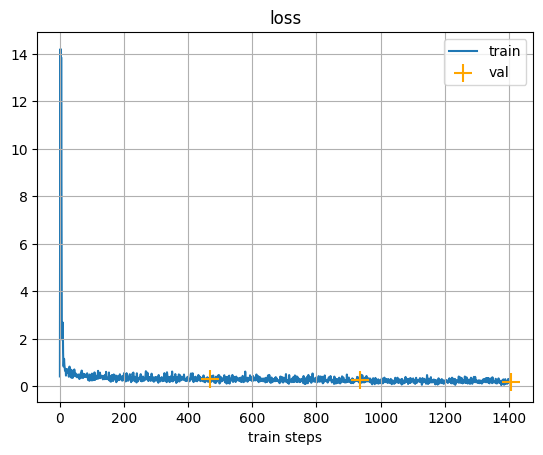

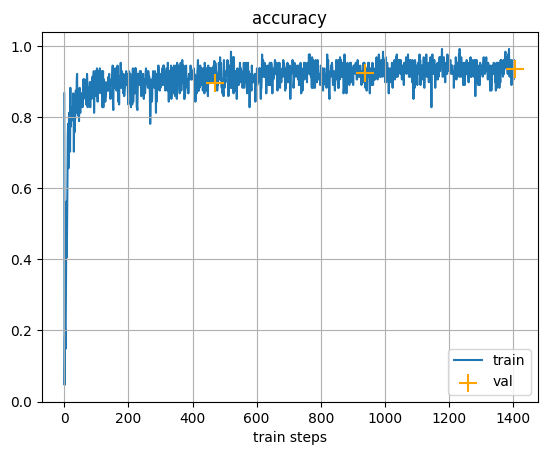

Epoch: 2, val loss: 0.19883599203032784, val accuracy: 0.936313271522522


In [36]:
# =====================================================================
# ОПТИМИЗАТОР RMSPROP И ОБУЧЕНИЕ
# =====================================================================

# В прошлой модели мы использовали Adam. Здесь преподаватель просит RMSprop.
# RMSprop (Root Mean Square Propagation) — это "дедушка" Адама. Он был придуман
# Джеффри Хинтоном прямо во время курса на Coursera.
#
# В чем его фишка? Он запоминает квадраты прошлых градиентов и делит текущий шаг
# на их корень. Если градиент по какому-то весу слишком сильно "скачет", RMSprop
# автоматически уменьшит для него скорость обучения (Learning Rate).
# Это делает обучение очень стабильным даже на сложных ландшафтах.
opt = torch.optim.RMSprop(modelBN.parameters(), lr=0.01)

# Запускаем обучение всего на 3 эпохи (вместо 10).
# Почему так мало? Потому что благодаря твоему BatchNorm2dLayer градиенты
# будут течь настолько ровно и быстро, что сеть обучится в разы быстрее,
# чем плоская сеть без нормализации!
train(modelBN, opt, 3)

In [37]:
for m in modelBN.modules():
    if isinstance(m, BatchNorm2dLayer):
        print(m)
        print("Parameters:", "weight       =", m.weight.data,  "bias        =", m.bias.data)
        print("Buffers:   ", "running_mean =", m.running_mean, "running_var =", m.running_var)
        print("\n")

BatchNorm2dLayer(1, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
Parameters: weight       = tensor([0.8597]) bias        = tensor([0.3505])
Buffers:    running_mean = tensor([0.1316]) running_var = tensor([0.0955])


BatchNorm2dLayer(2, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
Parameters: weight       = tensor([1.1432, 1.3561]) bias        = tensor([0.3382, 0.2555])
Buffers:    running_mean = tensor([5.6424e-01, 5.6052e-45]) running_var = tensor([1.0693e+00, 5.6052e-45])


BatchNorm2dLayer(4, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
Parameters: weight       = tensor([0.1685, 0.2082, 0.1412, 0.1353]) bias        = tensor([-0.0345,  0.0695, -0.0424,  0.0548])
Buffers:    running_mean = tensor([1.6170e-01, 1.4181e-01, 9.9040e-01, 4.1421e-34]) running_var = tensor([3.3206e-01, 3.2260e-01, 4.5657e+00, 9.2012e-35])


